In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# Top 5 UK banking stocks on LSE
tickers = {
    "HSBC": "HSBA.L",
    "Barclays": "BARC.L",
    "Lloyds": "LLOY.L",
    "NatWest": "NWG.L",
    "Standard Chartered": "STAN.L"
}

# Pull 6 months of data for all 5 at once
raw = yf.download(list(tickers.values()), period="6mo", auto_adjust=True)

# Extract closing prices
prices = raw["Close"]
prices.columns = list(tickers.keys())

print("Shape:", prices.shape)
print("\nFirst 5 rows:")
print(prices.head())

[*********************100%***********************]  5 of 5 completed


Shape: (127, 5)

First 5 rows:
                  HSBC     Barclays     Lloyds     NatWest  Standard Chartered
Date                                                                          
2025-09-22  383.305847  1031.163940  81.980003  512.396729         1442.566284
2025-09-23  389.255127  1036.361816  82.080002  514.795776         1454.062866
2025-09-24  385.005615  1036.761597  82.360001  515.595459         1452.063477
2025-09-25  376.306641  1024.766602  81.379997  504.999664         1425.071655
2025-09-26  382.555939  1038.360962  83.000000  520.193665         1448.564575


In [3]:
# Pandas does in 1 line what takes 20 lines in Excel
print("=== UK Banking Stocks — 6 Month Summary ===\n")
print(prices.describe().round(2))

=== UK Banking Stocks — 6 Month Summary ===

         HSBC  Barclays  Lloyds  NatWest  Standard Chartered
count  126.00    127.00  127.00   127.00              127.00
mean   432.44   1150.99   94.97   601.88             1665.13
std     40.71    108.74    7.65    44.19              152.87
min    357.76    963.89   81.38   505.00             1377.09
25%    394.66   1061.49   88.70   576.17             1554.28
50%    430.40   1149.99   95.76   608.96             1668.50
75%    473.60   1242.76  101.17   638.15             1807.46
max    501.54   1397.51  112.60   693.92             1905.43


In [4]:
# Calculate total return for each bank over 6 months
returns = ((prices.iloc[-1] - prices.iloc[0]) / prices.iloc[0] * 100).round(2)

print("=== 6-Month Performance ===\n")
for bank, ret in returns.sort_values(ascending=False).items():
    arrow = "▲" if ret > 0 else "▼"
    print(f"{arrow} {bank:<20} {ret:+.2f}%")

print(f"\nBest performer:  {returns.idxmax()} ({returns.max():+.2f}%)")
print(f"Worst performer: {returns.idxmin()} ({returns.min():+.2f}%)")

=== 6-Month Performance ===

▲ Barclays             +13.99%
▲ Lloyds               +13.98%
▲ Standard Chartered   +6.79%
▲ NatWest              +4.22%
▲ HSBC                 +0.64%

Best performer:  Barclays (+13.99%)
Worst performer: HSBC (+0.64%)


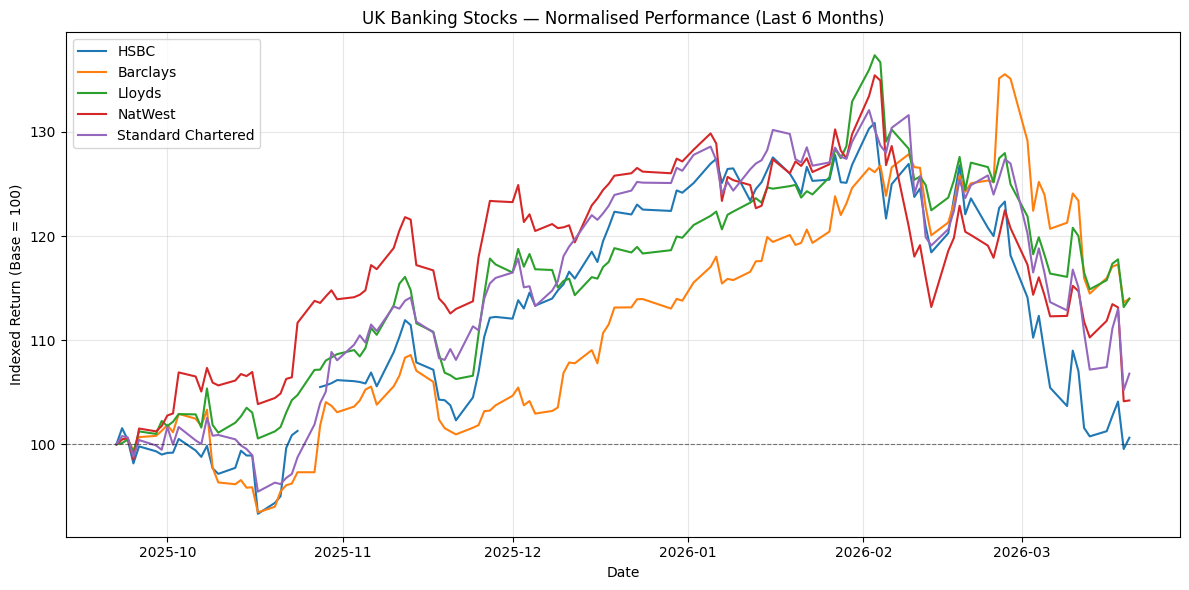

In [5]:
# Normalise to 100 so we can compare fairly regardless of share price
normalised = (prices / prices.iloc[0]) * 100

plt.figure(figsize=(12, 6))
for bank in normalised.columns:
    plt.plot(normalised.index, normalised[bank], label=bank, linewidth=1.5)

plt.axhline(y=100, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
plt.title('UK Banking Stocks — Normalised Performance (Last 6 Months)')
plt.ylabel('Indexed Return (Base = 100)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Daily returns for each bank
daily_returns = prices.pct_change().dropna()

# Annualised volatility — the risk metric every analyst uses
volatility = (daily_returns.std() * np.sqrt(252) * 100).round(2)

print("=== Risk Analysis — Annualised Volatility ===\n")
for bank, vol in volatility.sort_values(ascending=False).items():
    print(f"{bank:<20} {vol}%")

print(f"\nMost volatile:  {volatility.idxmax()} ({volatility.max()}%)")
print(f"Most stable:    {volatility.idxmin()} ({volatility.min()}%)")

=== Risk Analysis — Annualised Volatility ===

NatWest              30.73%
HSBC                 30.47%
Standard Chartered   28.57%
Barclays             27.4%
Lloyds               24.95%

Most volatile:  NatWest (30.73%)
Most stable:    Lloyds (24.95%)


=== Correlation Matrix ===

                    HSBC  Barclays  Lloyds  NatWest  Standard Chartered
HSBC                1.00      0.72    0.80     0.71                0.75
Barclays            0.72      1.00    0.70     0.62                0.70
Lloyds              0.80      0.70    1.00     0.80                0.67
NatWest             0.71      0.62    0.80     1.00                0.69
Standard Chartered  0.75      0.70    0.67     0.69                1.00


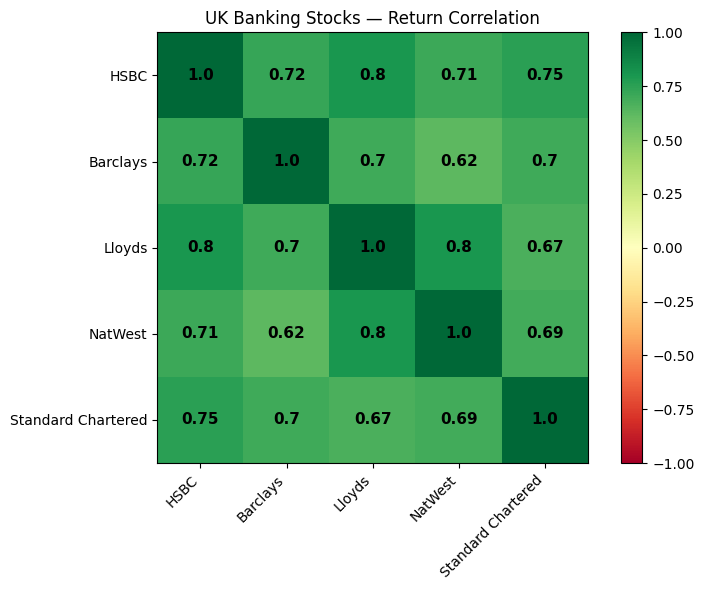

In [7]:
# Correlation — 1.0 means they move in perfect sync
correlation = daily_returns.corr().round(2)

print("=== Correlation Matrix ===\n")
print(correlation)

# Visualise as a heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(correlation, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im)

ax.set_xticks(range(len(correlation.columns)))
ax.set_yticks(range(len(correlation.columns)))
ax.set_xticklabels(correlation.columns, rotation=45, ha='right')
ax.set_yticklabels(correlation.columns)

for i in range(len(correlation)):
    for j in range(len(correlation.columns)):
        ax.text(j, i, correlation.iloc[i, j], 
                ha='center', va='center', fontsize=11, fontweight='bold')

ax.set_title('UK Banking Stocks — Return Correlation')
plt.tight_layout()
plt.show()